In [2]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import cupy as cp
import tqdm


best_parameters = {
    'spectral': ('Cz',          10 ,    'std'),
    'cwt':      ('BipolarDB',   2,      'median'),
    'dwt':      ('Laplacian',   10,     'median'),
    'mst':      ('BipolarDB',   60,     'median'),
    'sst':      ('CAR',         10,     'median'),
    'cc':       ('CAR',         1,      'std'),
    'plv':      ('Laplacian',   60,      'kurt'),
    'gcc':      ('CAR',         60,      'median'),
    'gplv':     ('Laplacian',   2,      'std'),
    'utm':      ('Laplacian',   20,     'std')
}

In [3]:
def load_data():
    """Load and prepare the dataset."""
    description = pd.read_csv(f'{DATA_FOLDER}/description.csv')
    labels = description['epilepsy'].to_numpy()
    subjects = description['subject'].to_numpy()
    unique_subjects = np.unique(description['subject'])
    
    subject_labels = []
    for subj in unique_subjects:
        lbl = labels[subjects == subj][0]
        subject_labels.append([subj, lbl])
    subject_labels = np.array(subject_labels)
    
    return description, labels, subjects, unique_subjects, subject_labels

def load_feature_data(feature_name):
    """Load and preprocess feature data using the best parameters for the given feature."""
    montage, segment_length, combiner = best_parameters[feature_name]
    data = np.load(f'{DATA_FOLDER}/{feature_name}_{montage}_{segment_length}s_{combiner}.npy')
    data = handle_complex_numbers(data)
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
    return data, montage, segment_length, combiner

def handle_complex_numbers(features):
    """Handle complex numbers and infinite values in features."""
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

In [14]:
DATA_FOLDER = '/space/gzanardini/emc_whole/split'

#load data
description, labels, subjects, unique_subjects, subject_labels = load_data()

chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

def plv_index_to_name(idx, ch=None):
    bands = ['raw','delta','theta','alpha','beta','gamma']
    if ch is None:
        ch = ['FP1_Lap','F3_Lap','C3_Lap','P3_Lap','F7_Lap','T3_Lap','T5_Lap','O1_Lap',
              'FZ_Lap','CZ_Lap','PZ_Lap','FP2_Lap','F4_Lap','C4_Lap','P4_Lap',
              'F8_Lap','T4_Lap','T6_Lap','O2_Lap']

    P   = len(ch)*(len(ch)-1)//2          # 171
    band_id, pair_id = divmod(idx, P)

    # recover the (j,k) pair that lives at position pair_id
    j = next(j for j in range(1, len(ch)) if j*(j+1)//2 > pair_id)
    k = pair_id - j*(j-1)//2

    return f"PLV_{bands[band_id]}_{ch[j]}-{ch[k]}"

feature_names = [plv_index_to_name(i, ch=chs) for i in range(1026)]



(141, 1026)
######


Processing plv: 100%|██████████| 141/141 [04:39<00:00,  1.99s/it]

Feature: plv - montage: Laplacian, segment_length: 60, combiner: kurt


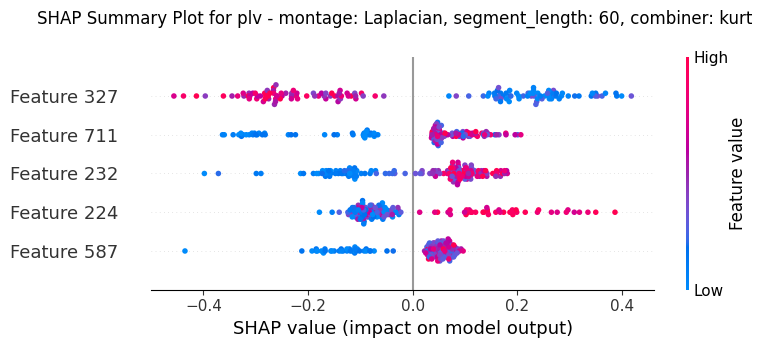

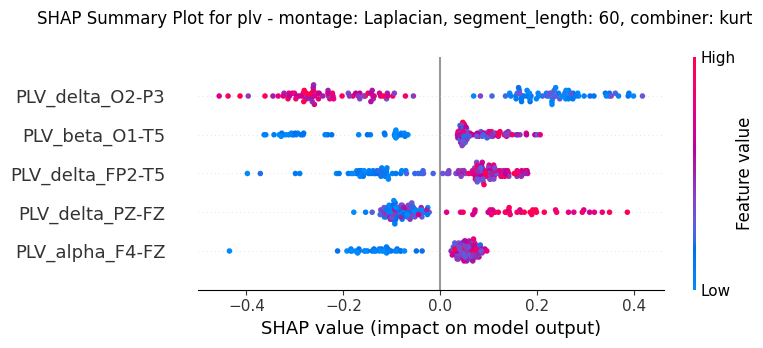

In [15]:
# for each of the best parameters, load the data and compute shapley values



for i, feature_name in enumerate(['plv']):
    data, montage, segment_length, combiner = load_feature_data(feature_name)
    print(data.shape)
    data = handle_complex_numbers(data)

    shap_values_folds = []
    print('######')

    for subj in tqdm.tqdm(unique_subjects, desc=f'Processing {feature_name}'):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]

        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]

        ratio = (len(y_train) - sum(y_train)) / sum(y_train)

        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01
        )

        model.fit(X_train, y_train)

        # Compute SHAP values
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer.shap_values(X_test)

        for shap_value in shap_values:
            shap_values_folds.append(shap_value)

    print(f'Feature: {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')
    fig = plt.figure(figsize=(8, 5))
    plt.suptitle(f'SHAP Summary Plot for {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')
    ax0=fig.add_subplot(111)
    shap.summary_plot(
        np.array(shap_values_folds),
        data, max_display=5, show=False)    
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(8, 5))
    plt.suptitle(f'SHAP Summary Plot for {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')
    ax0=fig.add_subplot(111)
    shap.summary_plot(
        np.array(shap_values_folds),
        data, max_display=5, show=False, feature_names=feature_names)    
    plt.tight_layout()
    if feature_name == 'plv':
        plt.savefig(f'shap_summary_{feature_name}_emc.pdf')
    plt.show()